In [4]:
# Install the Hugging Face Hub client in the active notebook runtime.
import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "huggingface_hub",
])

0

In [5]:
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_DIR = Path("/content") if IN_COLAB else Path.cwd()
DATA_DIR = PROJECT_DIR / "multisite-ppg"

print(f"Running in Colab: {IN_COLAB}")
print(f"Dataset folder: {DATA_DIR}")

Running in Colab: True
Dataset folder: /content/multisite-ppg


In [6]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="anonymous-ppg-dataset/multisite-ppg-submission",
    repo_type="dataset",
    allow_patterns="sample_data/*",
    local_dir=str(DATA_DIR),
)

sample_files = sorted((DATA_DIR / "sample_data").glob("**/*"))
print(f"Downloaded {sum(path.is_file() for path in sample_files)} files")

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Downloaded 23 files


In [10]:
import numpy as np

# `sample_data` is a directory, not a single `sample_data.npz` archive.
# Load one of the actual pre-windowed PPG sample files downloaded above.
sample_npz_path = (
    DATA_DIR
    / "sample_data"
    / "ppg_windowed_data"
    / "P7"
    / "alignment_windows_P7_Earring.npz"
)

if not sample_npz_path.is_file():
    raise FileNotFoundError(
        f"{sample_npz_path} was not found. Run the download cell above first."
    )

data = np.load(sample_npz_path)

print(f"Loaded: {sample_npz_path.name}")
print("Available arrays:", data.files)
print("PPG shape:", data["ppg_green"].shape)

Loaded: alignment_windows_P7_Earring.npz
Available arrays: ['t0_ms', 't1_ms', 'ecg', 'ecg_valid_len', 'ppg_fs', 'ppg_ir', 'ppg_green', 'hr_gt', 'n_peaks', 'accel_x', 'accel_y', 'accel_z']
PPG shape: (25668, 800)


In [11]:
from pathlib import Path

sample_dir = DATA_DIR / "sample_data"
print(sample_dir.exists())
print("file count:", sum(p.is_file() for p in sample_dir.glob("**/*")))
print("total size GB:", sum(p.stat().st_size for p in sample_dir.glob("**/*") if p.is_file()) / 1e9)

True
file count: 23
total size GB: 1.418792957


In [15]:
import matplotlib.pyplot as plt 
from  scipy.signal import butter , filtfilt,detrend 

In [16]:
def basic_ppg_preprocess(signal,fs=100,lowcut=0.5,highcut=8.0,order=4):
    signal=np.asarray(signal) 
    signal=np.squeeze(signal) 
    signal=np.nan_to_num(signal,nan=0.0,posinf=0.0,neginf=0.0)
    signal=detrend(signal)
    nyquist=fs/2 
    low = lowcut/nyquist 
    high = highcut/nyquist 
    b,a = butter(order,[low,high],btype='band') 
    filtered_signal = filtfilt(b,a,signal) 
    mean = np.mean(filtered_signal) 
    std = np.std(filtered_signal) 
    if std > 1e-8 : 
        normalized_signal = (filtered_signal - mean)/std 
    else : 
        normalized_signal = filtered_signal - mean 
    return normalized_signal 


In [18]:
raw_ppg=data['ppg_green'] 
print("Raw PPG shape:", raw_ppg.shape) 
processed_ppg =basic_ppg_preprocess(raw_ppg,fs=100,lowcut=0.5,highcut=8.0,order=4)

Raw PPG shape: (25668, 800)


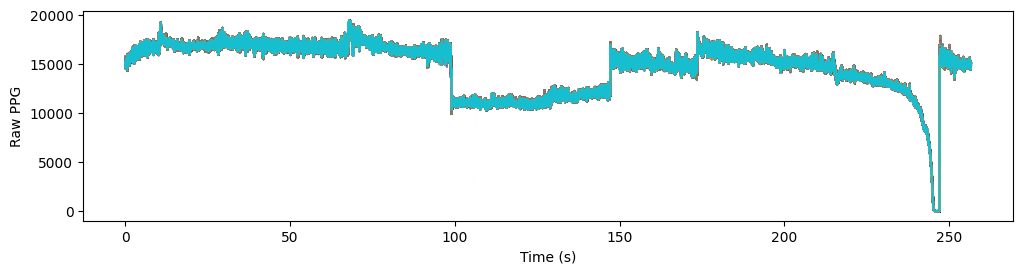

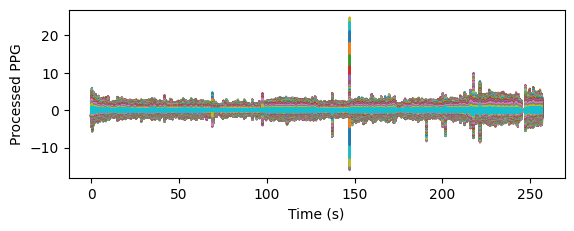

In [19]:
time = np.arange(len(raw_ppg))/100.0 
plt.figure(figsize=(12,6)) 
plt.subplot(2,1,1) 
plt.plot(time,raw_ppg) 
plt.xlabel('Time (s)')
plt.ylabel('Raw PPG')
plt.show()

plt.subplot(2,1,2) 
plt.plot(time,processed_ppg) 
plt.xlabel('Time (s)')
plt.ylabel('Processed PPG')
plt.show()

In [33]:
preprocessed_dataset = []
label_dataset = []
processed_files = []
skipped_files = []

for file_path in sorted((DATA_DIR / "sample_data" / "ppg_windowed_data").glob("**/*.npz")):
    with np.load(file_path) as data:
        if "ppg_green" not in data.files or "hr_gt" not in data.files:
            skipped_files.append((file_path.name, data.files))
            continue

        raw_ppg = data["ppg_green"]
        labels = data["hr_gt"]
        fs_values = np.asarray(data["ppg_fs"]).ravel() if "ppg_fs" in data.files else np.array([100.0])
        fs = float(fs_values[0])

    processed_ppg = basic_ppg_preprocess(raw_ppg, fs=fs, lowcut=0.5, highcut=8.0, order=4)
    preprocessed_dataset.append(processed_ppg)
    label_dataset.append(labels)
    processed_files.append(file_path.name)

print(f"Processed {len(processed_files)} files")
print(f"Skipped {len(skipped_files)} files without ppg_green/hr_gt")
if skipped_files:
    print("First skipped file:", skipped_files[0])


Processed 8 files
Skipped 0 files without ppg_green/hr_gt


In [34]:
if not preprocessed_dataset:
    raise ValueError("No PPG files were processed. Check DATA_DIR and ppg_windowed_data files.")
if not label_dataset:
    raise ValueError("No HR labels were processed. Check that the files contain hr_gt.")

X = np.concatenate(preprocessed_dataset, axis=0)
y = np.concatenate(label_dataset, axis=0)

print("Preprocessed dataset shape:", X.shape)
print("Label shape:", y.shape)


Preprocessed dataset shape: (292253, 800)
Label shape: (292253,)


In [35]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import numpy as np 
from torch.utils.data import Dataset, DataLoader 

In [36]:
X.shape 

(292253, 800)

In [37]:
y.shape

(292253,)

In [51]:
class PPGDataset(Dataset): 
    def __init__(self, X, y): 
        self.X = torch.tensor(X, dtype=torch.float32) 
        self.y = torch.tensor(y, dtype=torch.float32) 

    def __len__(self): 
        return len(self.X) 

    def __getitem__(self, idx): 
        x = self.X[idx].unsqueeze(-1)
        y = self.y[idx]
        return x, y 
    

In [61]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe=torch.zeros(max_len, d_model) 
        position=torch.arange(0,max_len,dtype=torch.float).unsqueeze(1)
        div_term=torch.exp(torch.arange(0,d_model,2).float()*(-np.log(10000.0)/d_model)) 
        pe[:,0::2]=torch.sin(position*div_term) 
        pe[:,1::2]=torch.cos(position*div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe) 
    def forward(self, x): 
        x = x + self.pe[:, :x.size(1), :]
        return x 

In [62]:
class PPGTransformer(nn.Module): 
    def __init__(self, input_dim=1, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1): 
        super().__init__() 
        self.input_fc = nn.Linear(input_dim, d_model) 
        self.pos_encoder = PositionalEncoding(d_model) 
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True) 
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers) 
        self.output_fc = nn.Linear(d_model, 1) 

    def forward(self, x): 
        x = self.input_fc(x) 
        x = self.pos_encoder(x) 
        x = self.transformer_encoder(x) 
        x = self.output_fc(x.mean(dim=1)) 
        return x.squeeze(-1)

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = PPGTransformer(input_dim=1, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1).to(device) 
model.to(device)
print(model)

PPGTransformer(
  (input_fc): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_fc): Linear(in_features=64, out_features=1, bias=True)
)


In [64]:
dataset=PPGDataset(X, y) 
train_size = int(0.8 * len(dataset)) 
val_size = len(dataset) - train_size 
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size]) 

In [65]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) 

In [66]:
criterion = nn.MSELoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001) 


In [ ]:
num_epochs = 20
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1)

        optimizer.zero_grad()
        outputs = model(X_batch).view(-1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(device)
            y_val = y_val.to(device).view(-1)

            val_outputs = model(X_val).view(-1)
            val_loss = criterion(val_outputs, y_val)
            val_running_loss += val_loss.item() * X_val.size(0)

    val_loss = val_running_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    test_losses.append(val_loss)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


Epoch [1/20], Train Loss: 404.8371, Val Loss: 154.2552
Epoch [2/20], Train Loss: 144.7607, Val Loss: 137.5350
Epoch [3/20], Train Loss: 134.6132, Val Loss: 128.8790
Epoch [4/20], Train Loss: 127.1085, Val Loss: 126.8756


In [ ]:
model.eval() 
all_predictions = [] 
all_targets = [] 
# jibon e lojja thakle aws chara kaj korbo na 

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).view(-1)

        outputs = model(X_batch).view(-1)
        all_predictions.append(outputs.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy()) 
all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets) 

In [ ]:
mse=np.mean((all_predictions - all_targets) ** 2)
print(f"Mean Squared Error on validation set: {mse:.4f}") 

In [ ]:
rmse = np.sqrt(mse) 
print(f"Root Mean Squared Error on validation set: {rmse:.4f}") 

In [ ]:
plt.figure(figsize=(12,6)) 
plt.scatter(all_targets, all_predictions, alpha=0.5)
plt.xlabel('True Heart Rate (bpm)')
plt.ylabel('Predicted Heart Rate (bpm)')
plt.title('Predicted vs True Heart Rate on Validation Set')
plt.show()